In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [78]:
df = pd.read_csv('loan_data.csv')
df.head(3)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1


In [79]:
df['person_education'].unique()

<ArrowStringArray>
['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
Length: 5, dtype: str

In [80]:
df['loan_intent'].unique()

<ArrowStringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

In [81]:
x = df.drop(columns='loan_status')
y = df['loan_status']

In [82]:
num_cols = x.select_dtypes(include='number').columns
cat_cols = x.select_dtypes(include='object').columns
print(num_cols)
print(cat_cols)

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='str')
Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='str')


C:\Users\HP\AppData\Local\Temp\ipykernel_4344\1169284844.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x.select_dtypes(include='object').columns


In [83]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size=0.8, random_state=42)

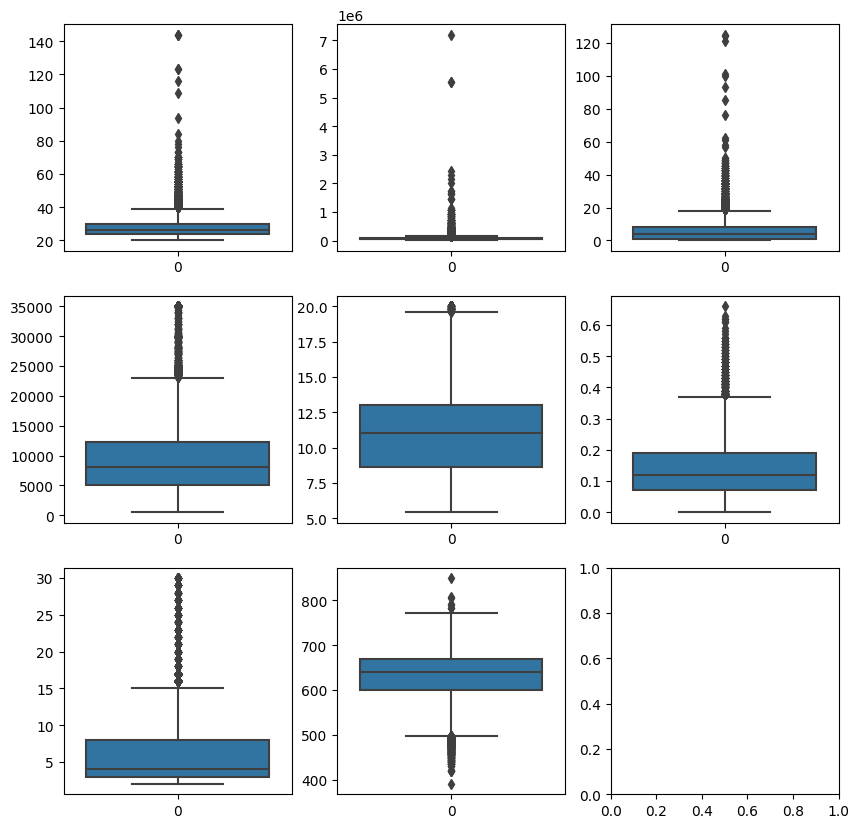

In [84]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
sns.boxplot(df['person_age'], ax=axes[0][0])
sns.boxplot(df['person_income'], ax=axes[0][1])
sns.boxplot(df['person_emp_exp'], ax=axes[0][2])
sns.boxplot(df['loan_amnt'], ax=axes[1][0])
sns.boxplot(df['loan_int_rate'], ax=axes[1][1])
sns.boxplot(df['loan_percent_income'], ax=axes[1][2])
sns.boxplot(df['cb_person_cred_hist_length'], ax=axes[2][0])
sns.boxplot(df['credit_score'], ax=axes[2][1])
plt.show()

<Axes: >

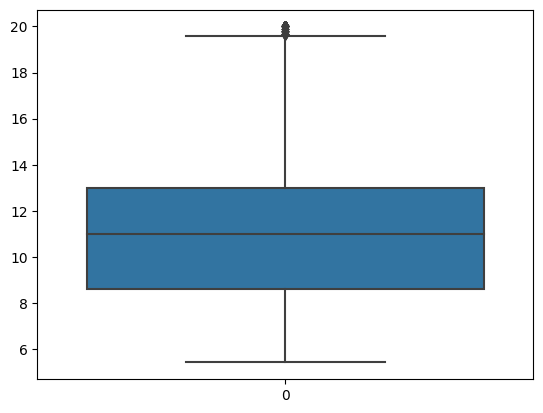

In [85]:
sns.boxplot(df['loan_int_rate'])


In [86]:
preprocessing = ColumnTransformer(
    transformers=[
        ('robust_scale', RobustScaler(), num_cols),
        ('encoding', OneHotEncoder(handle_unknown='ignore'), ['person_gender', 'person_home_ownership','loan_intent', 'previous_loan_defaults_on_file']),
        ('ord', OrdinalEncoder(categories=[['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]), ['person_education'])
    ]
)

In [87]:
main_pipeline = Pipeline(steps=[
    ('pre', preprocessing),
    ('model', LogisticRegression())
])

In [88]:
main_pipeline.fit(xtrain, ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('robust_scale', ...), ('encoding', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [89]:
ytrain_pred = main_pipeline.predict(xtrain)
ytest_pred = main_pipeline.predict(xtest)

In [90]:
# train data
cm_train = confusion_matrix(ytrain, ytrain_pred)
print(cm_train)
# test data
cm_test = confusion_matrix(ytest, ytest_pred)
print(cm_test)

[[26310  1700]
 [ 2007  5983]]
[[6551  439]
 [ 517 1493]]


In [91]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [92]:
print(cm_train[:, 0].sum())
print(cm_train[:, 1].sum())

28317
7683


### Precision

In [93]:
print(precision_score(ytrain, ytrain_pred, pos_label=0))
print(precision_score(ytrain, ytrain_pred, pos_label=1))

0.9291238478652399
0.7787322660419107


In [94]:
print(precision_score(ytest, ytest_pred, pos_label=0))
print(precision_score(ytest, ytest_pred, pos_label=1))


0.9268534238822863
0.7727743271221532


#### Precision conclusion

for train data

out of all (28317) predicted (loan status 0) samples, 92% samples are correctly predicted as loan status 0,
remaining 8% samples are wrongly predicted as (loan status 0).

out of all (7683) predicted (loan status 1) samples, 77% sample are correctly predicted as loan status 1, remaining 33% samples are wrongly predicted as (loan status 1).

same as for test data

In [95]:
print(cm_train[0, :].sum())
print(cm_train[1, :].sum())


28010
7990


### Recall

In [96]:
print(recall_score(ytrain, ytrain_pred, pos_label=0))
print(recall_score(ytrain, ytrain_pred, pos_label=1))


0.9393073902177793
0.748811013767209


In [97]:
print(recall_score(ytest, ytest_pred, pos_label=0))
print(recall_score(ytest, ytest_pred, pos_label=1))


0.9371959942775393
0.7427860696517413


#### Recall conclusion

for train data

out of all (28010) actual (loan status 0) samples, 93% samples are correctly predicted as loan status 0,
remaining 7% samples are wrongly predicted as loan status 1.

out of all (7990) actual (loan status 1) samples, 74% sample are correctly predicted as loan status 1, remaining 26% samples are wrongly predicted as loan status 0.

same as for test data

### F1- score

In [98]:
print(f1_score(ytrain, ytrain_pred, pos_label=0))
print(f1_score(ytrain, ytrain_pred, pos_label=1))

0.9341878672750191


0.7634785937599694


In [99]:
print(f1_score(ytest, ytest_pred, pos_label=0))
print(f1_score(ytest, ytest_pred, pos_label=1))

0.9319960165030587
0.7574835109081685


#### conclusion

for train data

for loan status 0, f1 score is 93% which means model has very good balance in identifying 0 labels

for loan status 1, f1 score is 76% which means model has good balance in identifying 1 labels

for test data

for loan status 0, f1 score is 93% which means model has very good balance in identifying 0 labels

for loan status 1, f1 score is 75% which means model has good balance in identifying 1 labels

## overall conclusion

since model has good balance in identifying the all the labels for both train and test data

hence the model performance is good.

### Model evaluation

In [100]:
# train data
print(classification_report(ytrain, ytrain_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     28010
           1       0.78      0.75      0.76      7990

    accuracy                           0.90     36000
   macro avg       0.85      0.84      0.85     36000
weighted avg       0.90      0.90      0.90     36000



In [101]:
# test data
print(classification_report(ytest, ytest_pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.84      9000
weighted avg       0.89      0.89      0.89      9000

